# PUMP — Healthy / faulty similarity (LR priority)

Merge four feature CSVs and compare each fault with healthy. No feature-subset search
or ensemble training is performed. All retained features are used.

**LR is the primary classifier:** healthy-versus-candidate F1 uses LR, and
`Primary_Merged_F1` is always the LR NO/YES F1. SVC and DT remain optional comparisons;
they do not replace LR if their scores are higher.

FeatureSimilarity retains the original pairwise RobustScaler / median-distance formula.
For F1, StandardScaler is fitted on training pumps only and LR uses liblinear.
Changing the classifier/scaling means new F1 scores are not directly equivalent to the
previous SVC-based separability scores. Similarity scores are unchanged for the same data.


**New: sections 7–9 compare every unique pair A/B and A+B versus the rest.**
To run only the new analysis, execute sections 1–4, then 7–9. The earlier
healthy-only comparison in sections 5–6 is optional.


## 1. Settings
`FAULT_IDS = None` compares every available class (including multifault classes if present).
To restrict the analysis, supply a list containing healthy and the desired faults.
`RUN_F1 = False` runs only the fast feature-similarity calculation.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.base import clone
from time import perf_counter
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import tqdm

SHOW_MAIN_PROGRESS = True
SHOW_DETAIL_PROGRESS = False

DATA_DIR = Path(rf"D:\ndoshi\VGuard\updated_architecture_experiments - Copy\pump_ml\V2\pump_ml_old_format\final(GIT)\VGUARD_Pump\pump_features")  # Example: Path(r"D:\PUMP_ML\features")
FILES = {
    "stats": "stats_features_2.csv",
    "analog": "ctvt_singlefault_peaks_freq.csv",
    "digital": "digital_feats_updt.csv",
    "physics": "physics_features.csv",
}
HEALTHY_ID = "00000000000_"
FAULT_IDS = None
RUN_F1 = True
N_FOLDS = 10
RANDOM_STATE = 42

LR_MAX_ITER = 8000  # Upper limit; fitting stops earlier if convergence is reached.
RUN_OTHER_MODELS = True  # False skips SVC/DT for a faster LR-only diagnostic.


## 2. Read and merge the four CSVs
Merge on `sample_id_key`, never on row position. Stats may contain multiple
`time_division` rows per sample; the other three files must have one row per sample.
Their features are repeated onto each stats division, as in the PUMP modeling table.
All Air/Water regions already encoded in the feature columns are retained.

Family prefixes prevent duplicate feature names. Identity columns are checked for
agreement and excluded from the numerical features. The inner merge keeps samples
present in all four files and reports any exclusions.


In [2]:
IDENTITY_COLS = {
    "sample_id_key", "fault_id", "pump_id", "sample_id", "pump_id_key", "fault_type",
    "time_division",
}
required = ["sample_id_key", "fault_id", "pump_id", "sample_id", "pump_id_key", "fault_type"]
tables = {}
metadata_parts = []

for family, filename in FILES.items():
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Update DATA_DIR / FILES in cell 1.")
    table = pd.read_csv(path, dtype={col: "string" for col in IDENTITY_COLS})
    table = table.loc[:, ~table.columns.str.startswith("Unnamed:")].copy()
    missing = set(required) - set(table.columns)
    if missing:
        raise ValueError(f"{filename}: missing identity columns {sorted(missing)}")
    for col in set(table.columns) & IDENTITY_COLS:
        table[col] = table[col].str.strip()
    if table[required].isna().any().any() or table[required].eq("").any().any():
        raise ValueError(f"{filename}: empty sample / fault / physical unit identity.")
    keys = ["sample_id_key"]
    if family == "stats" and "time_division" in table:
        keys.append("time_division")
    if table[keys].isna().any().any() or table.duplicated(keys).any():
        raise ValueError(f"{filename}: missing or duplicate key {keys}")
    tables[family] = table
    metadata_parts.append(table[[c for c in required
                                  if c in table]].drop_duplicates())

# Check that the same sample has consistent metadata in every feature file.
metadata = pd.concat(metadata_parts, ignore_index=True)
conflicts = metadata.groupby("sample_id_key").nunique(dropna=True).gt(1)
if conflicts.any().any():
    raise ValueError("Conflicting sample identities: " + str(conflicts.index[conflicts.any(axis=1)].tolist()[:10]))
metadata = metadata.groupby("sample_id_key", as_index=False).first()

feature_tables = {}
for family, table in tables.items():
    keys = ["sample_id_key"]
    if family == "stats" and "time_division" in table:
        keys.append("time_division")
    features = [c for c in table if c not in IDENTITY_COLS]
    numeric = table[features].apply(pd.to_numeric, errors="raise")
    numeric = numeric.add_prefix(f"{family}__")
    feature_tables[family] = pd.concat([table[keys], numeric], axis=1)

merged_df = feature_tables["stats"]
for family in ["analog", "digital", "physics"]:
    merged_df = merged_df.merge(feature_tables[family], on="sample_id_key",
                                how="inner", validate="many_to_one")
merged_df = merged_df.merge(metadata, on="sample_id_key", validate="many_to_one")
if merged_df.empty:
    raise ValueError("No common samples across the four CSVs. Check sample_id_key values.")

common_keys = set(merged_df["sample_id_key"])
merge_report = pd.DataFrame([
    {"file": family, "input_rows": len(table),
     "input_samples": table["sample_id_key"].nunique(),
     "samples_not_in_merge": len(set(table["sample_id_key"]) - common_keys)}
    for family, table in tables.items()
])
display(merge_report)

if FAULT_IDS is not None:
    absent = set(FAULT_IDS) - set(merged_df["fault_id"])
    if absent:
        raise ValueError(f"Requested faults missing after merge: {sorted(absent)}")
    merged_df = merged_df[merged_df["fault_id"].isin(FAULT_IDS)].copy()
if HEALTHY_ID not in set(merged_df["fault_id"]):
    raise ValueError(f"Healthy ID {HEALTHY_ID} must be present in the merged data.")

# Use the same finite, nonconstant feature set for every candidate.
feature_cols = [c for c in merged_df if c not in IDENTITY_COLS]
X = merged_df[feature_cols].replace([np.inf, -np.inf], np.nan)
keep = X.notna().all() & X.nunique().gt(1)
dropped_features = pd.DataFrame({
    "feature": X.columns[~keep],
    "reason": ["missing / infinite" if X[c].isna().any() else "constant"
               for c in X.columns[~keep]],
})
feature_cols = X.columns[keep].tolist()
if not feature_cols:
    raise ValueError("No complete, nonconstant numerical features remain. Check extraction outputs.")
merged_df = merged_df.drop(columns=dropped_features["feature"]).reset_index(drop=True)
print(f"Merged rows: {len(merged_df)} | Samples: {merged_df.sample_id_key.nunique()}")
print(f"Features retained: {len(feature_cols)} | Dropped: {len(dropped_features)}")
display(dropped_features)
display(merged_df.head())


,file,input_rows,input_samples,samples_not_in_merge
0,stats,315,315,0
1,analog,315,315,0
2,digital,315,315,0
3,physics,315,315,0


Merged rows: 315 | Samples: 315
Features retained: 2666 | Dropped: 6


,feature,reason
0,stats__WTF_water_3_col_0_mad,constant
1,stats__WTF_water_3_col_0_q05,constant
2,digital__AC1_air_0_col_1_rank_75_125,constant
3,digital__AC1_air_0_col_1_rank_175_225,constant
4,digital__GYR_water_2_col_2_rank_75_125,constant
5,digital__GYR_water_2_col_2_rank_175_225,constant


,sample_id_key,stats__SMG_air_0_col_0_rms,stats__SMG_air_0_col_0_kurt,stats__SMG_air_0_col_0_skew,stats__SMG_air_0_col_0_mad,stats__SMG_air_0_col_0_std,stats__SMG_air_0_col_0_q95,stats__SMG_air_0_col_0_q05,stats__SMG_air_1_col_0_rms,stats__SMG_air_1_col_0_kurt,...,physics__SMG_water_2_col_0_stability_observed,physics__SMG_water_2_col_0_settling_time_s,physics__SMG_water_3_col_0_cycle_count,physics__SMG_water_3_col_0_stability_observed,physics__SMG_water_3_col_0_settling_time_s,fault_id,pump_id,sample_id,pump_id_key,fault_type
0,00000000000_@1@1,2002.701704,-1.318254,0.016885,576.0,633.899188,2866.0,951.0,2045.396219,-1.455640,...,0.0,0.619990,45.0,1.0,0.247730,00000000000_,1,1,00000000000_@1,nofault
1,00000000000_@1@4,2095.957937,-1.335568,0.017380,625.0,682.722261,3014.0,967.0,2104.689526,-1.452496,...,0.0,0.620010,45.0,1.0,0.281565,00000000000_,1,4,00000000000_@1,nofault
2,00000000000_@2@1,2054.951097,-1.321857,0.024585,617.0,677.837205,2971.0,931.0,2047.700720,-1.546895,...,0.0,0.619998,45.0,0.0,0.619998,00000000000_,2,1,00000000000_@2,nofault
3,00000000000_@2@2,2107.736144,-1.321057,0.010428,612.0,672.591885,3015.0,989.0,2090.077084,-1.541303,...,0.0,0.619998,43.0,0.0,0.619998,00000000000_,2,2,00000000000_@2,nofault
4,00000000000_@2@3,2072.468106,-1.363611,0.032159,764.0,820.517889,3141.0,705.0,2012.584020,-1.538822,...,1.0,0.466150,46.0,1.0,0.262565,00000000000_,2,3,00000000000_@2,nofault


## 3. Pump-based splits for optional F1 checks
All samples and time divisions sharing a `pump_id_key` stay together.
The per-fault split assumes each `pump_id_key` belongs to one fault; the code checks this.
The keys must identify the actual physical pumps correctly.

Each fold tests about 30% of pumps per fault (four if there are more than ten).
A shuffled cyclic schedule balances pump exposure; the fold count is increased only
if necessary to give every pump a test appearance. This is a diagnostic schedule,
not exhaustive validation. A fault with only one pump cannot be evaluated this way;
set `RUN_F1=False` to calculate similarity alone.


In [3]:
def pump_splits(df, n_folds=10, random_state=42):
    if n_folds < 1:
        raise ValueError("n_folds must be positive")
    rng = np.random.default_rng(random_state)
    groups = df["pump_id_key"]
    if df.groupby("pump_id_key")["fault_id"].nunique().gt(1).any():
        raise ValueError("A pump_id_key appears under multiple faults. Use a shared-pump split "
                         "for this dataset, or RUN_F1=False for similarity only.")
    plans = []
    for fault in sorted(df["fault_id"].unique()):
        units = sorted(set(groups[df["fault_id"] == fault]))
        if len(units) < 2:
            raise ValueError(f"{fault}: F1 needs at least two pumps; set RUN_F1=False for similarity only.")
        units = [units[i] for i in rng.permutation(len(units))]
        n_test = 4 if len(units) > 10 else max(1, int(np.floor(0.3 * len(units) + 0.5)))
        n_test = min(n_test, len(units) - 1)
        plans.append((units, n_test))
        n_folds = max(n_folds, int(np.ceil(len(units) / n_test)))
    splits = []
    for fold in range(n_folds):
        test_groups = set()
        for units, n_test in plans:
            test_groups.update(units[(fold * n_test + j) % len(units)] for j in range(n_test))
        test_mask = groups.isin(test_groups).to_numpy()
        splits.append((np.flatnonzero(~test_mask), np.flatnonzero(test_mask)))
    return splits



def diagnostic_f1(df, feature_cols, splits, no_ids=None, random_state=42,
                  compare_models=None):
    y = (df["fault_id"].to_numpy() if no_ids is None
         else np.where(df["fault_id"].isin(no_ids), "NO", "YES"))
    models = {"LR": LogisticRegression(
        solver="liblinear", class_weight="balanced", C=1.0,
        max_iter=LR_MAX_ITER, random_state=random_state,
    )}
    if compare_models is None:
        compare_models = RUN_OTHER_MODELS
    if no_ids is not None and compare_models:
        models.update({
            "SVC": SVC(kernel="rbf", class_weight="balanced", random_state=random_state),
            "DT": DecisionTreeClassifier(class_weight="balanced", max_depth=5, random_state=random_state),
        })
    X = df[feature_cols].to_numpy(dtype=np.float64)
    truth, predictions = [], {name: [] for name in models}
    task = "Pair A vs B" if no_ids is None else "Merged NO/YES"
    for fold, (train, test) in enumerate(splits, start=1):
        started = perf_counter()
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train])
        X_test = scaler.transform(X[test])
        truth.extend(y[test])
        for name, model in models.items():
            fitted = clone(model).fit(X_train, y[train])
            predictions[name].extend(fitted.predict(X_test))
            if name == "LR":
                lr_iterations = int(np.max(fitted.n_iter_))
        if SHOW_DETAIL_PROGRESS:
            print(f"  {task}: fold {fold}/{len(splits)}, "
                  f"LR iterations={lr_iterations}, {perf_counter() - started:.1f}s", flush=True)
    return {name: f1_score(truth, pred, average="macro", zero_division=0)
            for name, pred in predictions.items()}


## 4. Healthy–fault similarity function
`FeatureSimilarity` uses every retained feature. F1 checks also use every retained
feature; there is no search for a best feature subset.


In [4]:
def healthy_fault_similarity(df, faulty_id, healthy_id, feature_cols,
                             run_f1=True, n_folds=10, random_state=42, splits=None,
                             compare_models=None):
    ids = sorted(df["fault_id"].unique())
    if healthy_id not in ids or faulty_id not in ids:
        raise ValueError("Healthy ID and candidate ID must both be in the dataframe.")
    pair = df[df["fault_id"].isin([healthy_id, faulty_id])].reset_index(drop=True)
    scaled = RobustScaler().fit_transform(pair[feature_cols])
    healthy_center = np.median(scaled[pair["fault_id"].eq(healthy_id)], axis=0)
    fault_center = np.median(scaled[pair["fault_id"].eq(faulty_id)], axis=0)
    distance = float(np.linalg.norm(healthy_center - fault_center))
    no_ids = list(dict.fromkeys([healthy_id, faulty_id]))
    remaining = [fault for fault in ids if fault not in no_ids]
    result = {
        "Candidate Fault": faulty_id,
        "No Fault": " + ".join(no_ids),
        "Faults": remaining,
        "FeatureSimilarity": 100.0 / (1.0 + distance),
        "Distinguishable_F1": np.nan,
        "LR_F1": np.nan, "SVC_F1": np.nan, "DT_F1": np.nan,
        "Primary_Model": "LR", "Primary_Merged_F1": np.nan,
        "Max_Merged_F1": np.nan,
    }
    if not run_f1:
        return result
    if faulty_id != healthy_id:
        pair_plan = pump_splits(pair, n_folds, random_state)
        result["Distinguishable_F1"] = diagnostic_f1(
            pair, feature_cols, pair_plan, random_state=random_state)["LR"]
    if remaining:  # Otherwise NO/YES would contain only one class.
        if splits is None:
            splits = pump_splits(df, n_folds, random_state)
        scores = diagnostic_f1(df, feature_cols, splits, no_ids, random_state,
                               compare_models=compare_models)
        result.update({f"{name}_F1": value for name, value in scores.items()})
        result["Primary_Merged_F1"] = scores["LR"]
        result["Max_Merged_F1"] = max(scores.values())  # Reference only; not model priority.
    return result


## 5. Compare every included fault
The healthy row is a reference: similarity is 100 and healthy-vs-itself F1 is blank.
Its merged F1 checks are the ordinary healthy vs all-faults baseline.


In [5]:
shared_splits = pump_splits(merged_df, N_FOLDS, RANDOM_STATE) if RUN_F1 else None
if shared_splits is not None:
    print("F1 folds:", len(shared_splits))
results = []
if SHOW_MAIN_PROGRESS:
    fault_iter = tqdm.tqdm(sorted(merged_df["fault_id"].unique()), desc="Healthy-fault comparison")
else:
    fault_iter = sorted(merged_df["fault_id"].unique())
for fault in fault_iter:
    if SHOW_DETAIL_PROGRESS:
        print("Comparing with healthy:", fault)
    results.append(healthy_fault_similarity(
        merged_df, faulty_id=fault, healthy_id=HEALTHY_ID,
        feature_cols=feature_cols, run_f1=RUN_F1,
        n_folds=N_FOLDS, random_state=RANDOM_STATE, splits=shared_splits,
    ))
healthy_like_df = pd.DataFrame(results).sort_values(
    ["FeatureSimilarity", "Distinguishable_F1", "Primary_Merged_F1"],
    ascending=[False, True, False], na_position="last",
).reset_index(drop=True)
display(healthy_like_df.round(4))


F1 folds: 10


Healthy-fault comparison: 100%|██████████| 18/18 [00:29<00:00,  1.62s/it]


,Candidate Fault,No Fault,Faults,FeatureSimilarity,Distinguishable_F1,LR_F1,SVC_F1,DT_F1,Primary_Model,Primary_Merged_F1,Max_Merged_F1
0,00000000000_,00000000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",100.0000,NaN,0.5203,0.4921,0.5550,LR,0.5203,0.5550
1,00000100000_,00000000000_ + 00000100000_,"[00000000001_, 00000000010_, 00000000100_, 000...",3.2838,0.6626,0.5276,0.5267,0.6932,LR,0.5276,0.6932
2,30000000000_,00000000000_ + 30000000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",3.1418,0.7066,0.6262,0.5390,0.7074,LR,0.6262,0.7074
3,20000000000_,00000000000_ + 20000000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.9957,0.7176,0.5636,0.4913,0.6640,LR,0.5636,0.6640
4,00000200000_,00000000000_ + 00000200000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.9172,0.8787,0.6008,0.4775,0.5346,LR,0.6008,0.6008
5,40000000000_,00000000000_ + 40000000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.8692,0.7462,0.5644,0.5042,0.6679,LR,0.5644,0.6679
6,00010000000_,00000000000_ + 00010000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.8599,0.8393,0.5551,0.6404,0.5889,LR,0.5551,0.6404
7,10000000000_,00000000000_ + 10000000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.8422,0.7010,0.6195,0.5482,0.7001,LR,0.6195,0.7001
8,00000000200_,00000000000_ + 00000000200_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.8027,0.8528,0.5642,0.4798,0.5768,LR,0.5642,0.5768
9,00001000000_,00000000000_ + 00001000000_,"[00000000001_, 00000000010_, 00000000100_, 000...",2.7688,0.9616,0.4984,0.4798,0.5295,LR,0.4984,0.5295


**Reading the results**

- **FeatureSimilarity (0–100):** higher means closer median feature vectors after
  pairwise RobustScaler. It is not a probability. Its magnitude depends on the feature
  count and pairwise scale, so do not directly compare it with FAN scores.
- **Distinguishable_F1 (0–1):** now uses **LR** to separate healthy from the candidate
  on held-out pumps. Higher means easier to distinguish; low F1 alone does not prove similarity.
- **LR_F1 / SVC_F1 / DT_F1:** macro F1 for the hypothetical labeling of healthy + candidate
  as NO and remaining faults as YES. Original labels are not changed.
- **Primary_Model / Primary_Merged_F1:** LR and its merged F1, regardless of which
  comparison model scores highest. LR also supplies the last ranking tie-breaker.
- **Max_Merged_F1:** highest score among the models actually run, for reference only.
  SVC/DT cells are blank when `RUN_OTHER_MODELS=False`.

F1 pools predictions across folds. All retained features are used without ANOVA.
Any convergence warnings remain visible; a high iteration cap does not guarantee
convergence. Fold progress shows actual LR iterations and elapsed time.
FeatureSimilarity remains the main ranking criterion. Healthy-versus-itself F1 is blank.

This is exploratory analysis, not proof that a real fault can be accepted as healthy.


## 6. Plot and save results
The healthy reference is omitted from the bar chart so differences between faults
are easier to see. Uncomment the last line only if you also want the merged CSV.


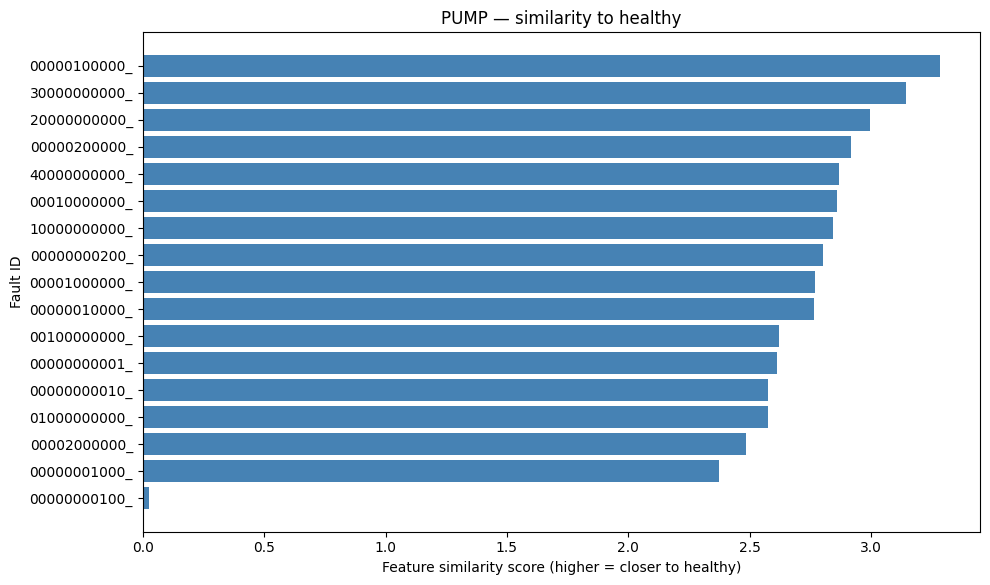

Saved: D:\ndoshi\VGuard\updated_architecture_experiments - Copy\pump_ml\V2\pump_ml_old_format\final(GIT)\VGUARD_Pump\pump_features\healthy_fault_similarity_results\pump_healthy_fault_similarity.csv


In [6]:
plot_df = healthy_like_df[healthy_like_df["Candidate Fault"] != HEALTHY_ID]
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    ax.barh(plot_df["Candidate Fault"], plot_df["FeatureSimilarity"], color="steelblue")
    ax.invert_yaxis()
    ax.set_xlabel("Feature similarity score (higher = closer to healthy)")
    ax.set_ylabel("Fault ID")
    ax.set_title("PUMP — similarity to healthy")
    fig.tight_layout()
    plt.show()

OUTPUT_DIR = DATA_DIR / "healthy_fault_similarity_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
healthy_like_df.to_csv(OUTPUT_DIR / "pump_healthy_fault_similarity.csv", index=False)
# merged_df.to_csv(OUTPUT_DIR / "pump_merged_features.csv", index=False)
print("Saved:", OUTPUT_DIR / "pump_healthy_fault_similarity.csv")


## 7. All-pair settings
Each unordered pair is tested once: A/B is the same pair as B/A; no A/A comparisons.
By default, pairs include healthy and every fault present in `merged_df`.
For 18 classes this gives 153 pairs. With 17 faulty classes and healthy pairs disabled,
there are 136 pairs; healthy still belongs to the remaining classes for A+B-versus-rest.

LR is primary. SVC/DT comparisons are disabled **only for this new section** by default
to reduce runtime. All retained features are still used; there is no subset search.
`PAIR_RUN_F1=False` calculates only feature similarity.


In [7]:
from itertools import combinations
import tqdm

INCLUDE_HEALTHY_IN_PAIRS = True
PAIR_RUN_F1 = RUN_F1
PAIR_RUN_OTHER_MODELS = False  # True adds SVC/DT to the A+B-versus-rest test.
PAIR_N_FOLDS = N_FOLDS


## 8. Compare one pair or every pair
The first test uses only rows belonging to A or B. The second test uses all rows:
A+B are one group and all remaining included classes form the other group.
Neither A nor B is relabeled as healthy in your original dataframe.

The helper reuses the existing similarity calculation, with A in the first reference
position and B in the candidate position, then gives the outputs neutral pair labels.
F1 is macro F1 pooled across held-out-pump predictions, exactly as above.


In [8]:
def fault_pair_similarity(df, fault_a, fault_b, feature_cols,
                          run_f1=True, n_folds=8, random_state=42,
                          compare_models=False, splits=None):
    if fault_a == fault_b:
        raise ValueError("Choose two different fault IDs.")
    # Sorting makes A/B and B/A identical, including their displayed labels.
    fault_a, fault_b = sorted([fault_a, fault_b])
    result = healthy_fault_similarity(
        df, faulty_id=fault_b, healthy_id=fault_a, feature_cols=feature_cols,
        run_f1=run_f1, n_folds=n_folds, random_state=random_state,
        splits=splits, compare_models=compare_models,
    )
    return {
        "Fault_A": fault_a,
        "Fault_B": fault_b,
        "Combined_Group": f"{fault_a} + {fault_b}",
        "Remaining_Faults": result["Faults"],
        "FeatureSimilarity": result["FeatureSimilarity"],
        "A_vs_B_LR_F1": result["Distinguishable_F1"],
        "AB_vs_Rest_LR_F1": result["LR_F1"],
        "AB_vs_Rest_SVC_F1": result["SVC_F1"],
        "AB_vs_Rest_DT_F1": result["DT_F1"],
        "Primary_Model": "LR",
        "Primary_Merged_F1": result["LR_F1"],
    }


def compare_all_fault_pairs(df, feature_cols, include_healthy=True,
                            healthy_id=HEALTHY_ID, run_f1=True, n_folds=8,
                            random_state=42, compare_models=False):
    df = df.reset_index(drop=True)
    pair_ids = sorted(df["fault_id"].unique())
    if not include_healthy:
        pair_ids = [fault for fault in pair_ids if fault != healthy_id]
    pairs = list(combinations(pair_ids, 2))
    if not pairs:
        raise ValueError("At least two eligible fault IDs are required.")
    # This shared plan applies to the full dataframe for A+B versus rest.
    # Each A-versus-B test builds its own plan using only those two classes.
    has_rest = df["fault_id"].nunique() > 2
    splits = pump_splits(df, n_folds, random_state) if run_f1 and has_rest else None
    print(f"Unique pairs: {len(pairs)} | Primary model: LR", flush=True)
    if splits is not None:
        print(f"A+B versus rest folds: {len(splits)}", flush=True)
    rows = []
    for number, (fault_a, fault_b) in tqdm.tqdm(enumerate(pairs, start=1), total=len(pairs), desc="Comparing all fault pairs"):
        started = perf_counter()
        print(f"\nPair {number}/{len(pairs)}: {fault_a} + {fault_b}", flush=True)
        rows.append(fault_pair_similarity(
            df, fault_a, fault_b, feature_cols, run_f1=run_f1,
            n_folds=n_folds, random_state=random_state,
            compare_models=compare_models, splits=splits,
        ))
        print(f"Pair completed in {perf_counter() - started:.1f}s", flush=True)
    return pd.DataFrame(rows).sort_values(
        ["FeatureSimilarity", "A_vs_B_LR_F1", "AB_vs_Rest_LR_F1"],
        ascending=[False, True, False], na_position="last",
    ).reset_index(drop=True)

## 9. Run all pairs and save
This evaluates many more pairs than healthy-only testing, so it takes longer even
with LR alone. Progress shows the current pair, fold, iterations and time.
All-pair results are saved separately from healthy-only results.


In [ ]:
all_pairs_df = compare_all_fault_pairs(
    merged_df, feature_cols,
    include_healthy=INCLUDE_HEALTHY_IN_PAIRS,
    healthy_id=HEALTHY_ID,
    run_f1=PAIR_RUN_F1,
    n_folds=PAIR_N_FOLDS,
    random_state=RANDOM_STATE,
    compare_models=PAIR_RUN_OTHER_MODELS,
)
with pd.option_context("display.max_rows", None):
    display(all_pairs_df.round(4))

OUTPUT_DIR = DATA_DIR / "healthy_fault_similarity_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
all_pairs_df.to_csv(OUTPUT_DIR / "pump_all_fault_pairs_similarity.csv", index=False)
print("Saved:", OUTPUT_DIR / "pump_all_fault_pairs_similarity.csv")


Unique pairs: 153 | Primary model: LR
A+B versus rest folds: 10


Comparing all fault pairs:   0%|          | 0/153 [00:00<?, ?it/s]


Pair 1/153: 00000000000_ + 00000000001_
Pair completed in 0.7s


Comparing all fault pairs:   1%|          | 1/153 [00:00<01:44,  1.46it/s]


Pair 2/153: 00000000000_ + 00000000010_
Pair completed in 0.7s


...


Pair 134/153: 00010000000_ + 01000000000_
Pair completed in 0.7s


Comparing all fault pairs:  88%|████████▊ | 134/153 [01:33<00:13,  1.38it/s]


Pair 135/153: 00010000000_ + 10000000000_
Pair completed in 0.9s


Comparing all fault pairs:  88%|████████▊ | 135/153 [01:34<00:13,  1.31it/s]


Pair 136/153: 00010000000_ + 20000000000_


**How to interpret the pair results**

| Column | Meaning |
|---|---|
| FeatureSimilarity | Higher = closer median feature vectors after pairwise scaling. |
| A_vs_B_LR_F1 | Higher = LR separates A from B better on held-out pumps. Lower means poorer separation, not proof of similarity. |
| AB_vs_Rest_LR_F1 | Higher = LR separates the combined A+B group from remaining classes better. It does not measure whether A and B resemble each other. |
| AB_vs_Rest_SVC_F1 / DT_F1 | Optional comparison scores for the combined group. Blank when not run. |

Pairs worth examining have relatively high FeatureSimilarity, weak A-versus-B
separation, and strong A+B-versus-rest separation. There is no universal cutoff:
inspect their feature distributions and pump-level behavior before deciding to merge labels.
If only A and B exist in the dataframe, the pair test still runs but versus-rest F1 is
blank because there are no remaining classes. `FAULT_IDS`, if set in section 1,
defines the entire analysis population; “rest” means the other classes in that dataframe.

These are exploratory rankings. Comparing many pairs on the same folds does not
provide an independent final evaluation of whichever pair you later choose.
